In [19]:
%pip install --upgrade tensorflow


# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLP libraries
import re
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# POS tagging (spaCy)
import spacy

from spacy.cli import download

download("en_core_web_sm") 

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Train-test split
from sklearn.model_selection import train_test_split

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Download required NLTK data
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

Note: you may need to restart the kernel to use updated packages.


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/mohammadubaid/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/mohammadubaid/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mohammadubaid/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/mohammadubaid/nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/mohammadubaid/nltk_data...


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 13.0 MB/s  0:00:00 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/mohammadubaid/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mohammadubaid/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/mohammadubaid/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [20]:
import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)


print("Files in dataset:", os.listdir(path))



# Load dataset
csv_path = os.path.join(path, "IMDB Dataset.csv")
df = pd.read_csv(csv_path)


print("IMDB DATASET LOADED")


# Show first 5 rows
print("\nSample Data:")
print(df.head())

# Shape
print("\nDataset Shape:")
print(df.shape)

# Columns
print("\nColumns:")
print(df.columns)

# Sentiment distribution
print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())


Path to dataset files: /Users/mohammadubaid/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1
Files in dataset: ['IMDB Dataset.csv']
IMDB DATASET LOADED

Sample Data:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Dataset Shape:
(50000, 2)

Columns:
Index(['review', 'sentiment'], dtype='str')

Sentiment Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [21]:
import re

# CLEANING FUNCTION
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)                    # remove HTML tags
    text = re.sub(r"http\S+|www\S+", "", text)           # remove URLs
    text = re.sub(r"[^a-z\s]", "", text)                 # remove numbers & punctuation
    text = re.sub(r"\s+", " ", text).strip()             # remove extra spaces
    return text

# Apply cleaning to dataset
df['clean_review'] = df['review'].apply(clean_text)


print("ORIGINAL REVIEW:\n")
print(df['review'][0])

print("\nCLEANED REVIEW:\n")
print(df['clean_review'][0])

ORIGINAL REVIEW:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show

In [22]:

from nltk.tokenize import sent_tokenize, word_tokenize

# Select a sample cleaned review
sample_review = df['clean_review'][0]

# Sentence Tokenization
sentences = sent_tokenize(sample_review)

# Word Tokenization
words = word_tokenize(sample_review)


print("ORIGINAL TEXT:\n")
print(sample_review)

print("\nSENTENCES:\n")
print(sentences)

print("\nWORDS:\n")
print(words[:20])   # show first 20 words only

ORIGINAL TEXT:

one of the other reviewers has mentioned that after watching just oz episode youll be hooked they are right as this is exactly what happened with methe first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordit is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far awayi would say the main appeal of the show is due to the fact that it goes where other shows wouldnt dare forget 

In [23]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords

# Load stopwords
stop_words = set(stopwords.words('english'))

# Tokenize sample review
words = word_tokenize(df['clean_review'][0])

# Remove stopwords
filtered_words = [word for word in words if word not in stop_words]

# Output
print("ORIGINAL WORDS:\n")
print(words[:20])

print("\nAFTER STOPWORD REMOVAL:\n")
print(filtered_words[:20])

ORIGINAL WORDS:

['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', 'oz', 'episode', 'youll', 'be', 'hooked', 'they', 'are', 'right', 'as']

AFTER STOPWORD REMOVAL:

['one', 'reviewers', 'mentioned', 'watching', 'oz', 'episode', 'youll', 'hooked', 'right', 'exactly', 'happened', 'methe', 'first', 'thing', 'struck', 'oz', 'brutality', 'unflinching', 'scenes', 'violence']


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/mohammadubaid/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/mohammadubaid/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mohammadubaid/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/mohammadubaid/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/mohammadubaid/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [24]:
# Use cleaned review
sample_text = df['clean_review'][0]

# Process using spaCy
doc = nlp(sample_text)

print("WORD\t\tPOS      TAG")
print("="*30)

# Show first 20 words with POS
for token in doc[:20]:
    print(f"{token.text}\t\t{token.pos_}")

WORD		POS      TAG
one		NUM
of		ADP
the		DET
other		ADJ
reviewers		NOUN
has		AUX
mentioned		VERB
that		SCONJ
after		ADP
watching		VERB
just		ADV
oz		ADP
episode		NOUN
you		PRON
ll		AUX
be		AUX
hooked		VERB
they		PRON
are		AUX
right		ADJ


In [25]:
from nltk.stem import WordNetLemmatizer

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Tokenize sample review
words = word_tokenize(df['clean_review'][0])

# Apply lemmatization
lemmatized_words = [lemmatizer.lemmatize(word) for word in words]


print("ORIGINAL WORDS:\n")
print(words[:20])

print("\nLEMMATIZED WORDS:\n")
print(lemmatized_words[:20])

ORIGINAL WORDS:

['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', 'oz', 'episode', 'youll', 'be', 'hooked', 'they', 'are', 'right', 'as']

LEMMATIZED WORDS:

['one', 'of', 'the', 'other', 'reviewer', 'ha', 'mentioned', 'that', 'after', 'watching', 'just', 'oz', 'episode', 'youll', 'be', 'hooked', 'they', 'are', 'right', 'a']


In [26]:

df['sentiment_encoded'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

# Show sample
print("SAMPLE DATA:\n")
print(df[['review', 'sentiment', 'sentiment_encoded']].head())

# Check distribution
print("\nENCODED DISTRIBUTION:")
print(df['sentiment_encoded'].value_counts())

SAMPLE DATA:

                                              review sentiment  \
0  One of the other reviewers has mentioned that ...  positive   
1  A wonderful little production. <br /><br />The...  positive   
2  I thought this was a wonderful way to spend ti...  positive   
3  Basically there's a family where a little boy ...  negative   
4  Petter Mattei's "Love in the Time of Money" is...  positive   

   sentiment_encoded  
0                  1  
1                  1  
2                  1  
3                  0  
4                  1  

ENCODED DISTRIBUTION:
sentiment_encoded
1    25000
0    25000
Name: count, dtype: int64


In [27]:
from sklearn.model_selection import train_test_split

# Features and labels
X = df['clean_review']
y = df['sentiment_encoded']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # keeps class balance
)

# Output
print("TRAINING DATA SIZE:", len(X_train))
print("TESTING DATA SIZE:", len(X_test))

print("\nTRAIN LABEL DISTRIBUTION:")
print(y_train.value_counts())

print("\nTEST LABEL DISTRIBUTION:")
print(y_test.value_counts())

TRAINING DATA SIZE: 40000
TESTING DATA SIZE: 10000

TRAIN LABEL DISTRIBUTION:
sentiment_encoded
1    20000
0    20000
Name: count, dtype: int64

TEST LABEL DISTRIBUTION:
sentiment_encoded
0    5000
1    5000
Name: count, dtype: int64


In [28]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Initialize tokenizer
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")

# Fit on training data
tokenizer.fit_on_texts(X_train)

# Convert text → sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding sequences
max_length = 200

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post')

# Output
print("TRAIN SHAPE:", X_train_pad.shape)
print("TEST SHAPE:", X_test_pad.shape)

TRAIN SHAPE: (40000, 200)
TEST SHAPE: (10000, 200)


In [29]:
import os
import zipfile
import urllib.request

url = "https://nlp.stanford.edu/data/glove.6B.zip"
zip_path = "glove.6B.zip"


if not os.path.exists(zip_path):
    print("Downloading GloVe...")
    urllib.request.urlretrieve(url, zip_path)


with zipfile.ZipFile(zip_path, 'r') as z:
    print("ZIP verified successfully")
    print("Files:", z.namelist())


with zipfile.ZipFile(zip_path, 'r') as z:
    z.extract("glove.6B.100d.txt", "glove")

print("GloVe extracted successfully!")




ZIP verified successfully
Files: ['glove.6B.50d.txt', 'glove.6B.100d.txt', 'glove.6B.200d.txt', 'glove.6B.300d.txt']
GloVe extracted successfully!


In [30]:
import numpy as np

# Load GloVe file
embedding_index = {}

with open("glove/glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = vector

print("Total GloVe words loaded:", len(embedding_index))

#  CREATE EMBEDDING MATRIX

embedding_dim = 100
word_index = tokenizer.word_index

# Limit vocab size
max_words = 10000

embedding_matrix = np.zeros((max_words, embedding_dim))

for word, i in word_index.items():
    if i < max_words:
        vector = embedding_index.get(word)
        if vector is not None:
            embedding_matrix[i] = vector

print("Embedding Matrix Shape:", embedding_matrix.shape)

Total GloVe words loaded: 400000
Embedding Matrix Shape: (10000, 100)


Embedding Matrix Shape: (10000, 100)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 198, 256)       │        77,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,093,569 (4.17 MB)

 Trainable params: 1,093,569 (4.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 29s 108ms/step - accuracy: 0.7457 - loss: 0.5029 - val_accuracy: 0.8535 - val_loss: 0.3329 - learning_rate: 0.0010
Epoch 2/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 105ms/step - accuracy: 0.8723 - loss: 0.3181 - val_accuracy: 0.8711 - val_loss: 0.2951 - learning_rate: 0.0010
Epoch 3/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 103ms/step - accuracy: 0.9083 - loss: 0.2450 - val_accuracy: 0.8760 - val_loss: 0.2908 - learning_rate: 0.0010
Epoch 4/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9339 - loss: 0.1842
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 102ms/step - accuracy: 0.9363 - loss: 0.1802 - val_accuracy: 0.8860 - val_loss: 0.2938 - learning_rate: 0.0010
Epoch 5/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9689 - loss: 0.1056
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 ━━━━━━━━━━━━━━━━━━━━ 28s 113ms/step - accuracy: 0.9685 -

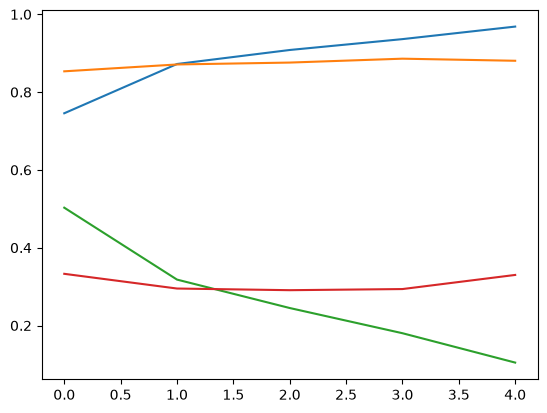

In [31]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


max_words = 10000      # Vocabulary size
max_length = 200       # Maximum review length
embedding_dim = 100    


print("Embedding Matrix Shape:", embedding_matrix.shape)


model = Sequential([

   
    Input(shape=(max_length,)),

    
    Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=True
    ),

    
    Conv1D(
        filters=256,
        kernel_size=3,
        activation='relu'
    ),

    
    GlobalMaxPooling1D(),

    
    Dense(
        64,
        activation='relu'
    ),

    
    Dropout(0.5),

    
    Dense(
        1,
        activation='sigmoid'
    )
])


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


model.build(input_shape=(None, max_length))

model.summary()


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    verbose=1
)


history = model.fit(
    X_train_pad,
    y_train,
    epochs=12,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr]
)


loss, accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print("\nTest Accuracy:", accuracy)


y_pred_prob = model.predict(X_test_pad)

y_pred = (y_pred_prob > 0.5).astype(int)


from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])



In [32]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Compile model
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2
)



313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Accuracy : 0.8754
Accuracy : 87.54%


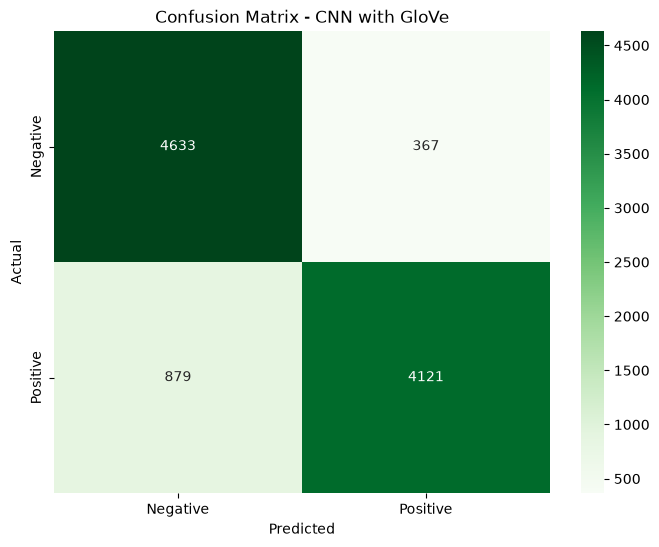


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Negative       0.84      0.93      0.88      5000
    Positive       0.92      0.82      0.87      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

METRICS:
Precision: 0.9182
Recall:    0.8242
F1-Score:  0.8687


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Predictions
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

# 2. Accuracy Print
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy:.4f}")

print(f"Accuracy : {accuracy*100:.2f}%")

# 3. Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - CNN with GloVe')
plt.show()

# 4. Classification Report
# Setting target_names ensures the labels appear as Negative/Positive
report = classification_report(y_test, y_pred, target_names=['Negative', 'Positive'])
print("\nCLASSIFICATION REPORT:")
print(report)

# 5. Additional METRICS (Precision/Recall/F1)
from sklearn.metrics import precision_score, recall_score, f1_score
print("METRICS:")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")


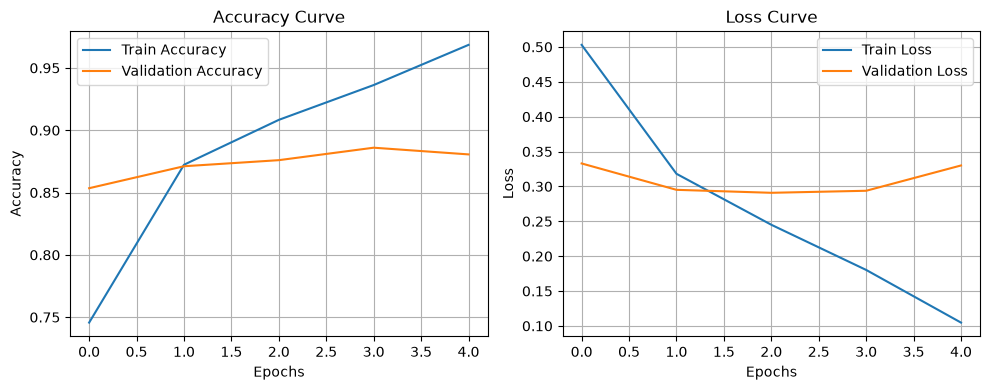

In [34]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.grid(True)

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("loss_curve.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

In [35]:
model.save("sentiment_cnn_glove.h5")

print("Model saved successfully")

Model saved successfully


In [36]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved successfully")

Tokenizer saved successfully
